<h1>Train — DenseNet-121</h1>

Trains and evaluates DenseNet-121 using the tuned hyperparameters from `ARCH_HYPERPARAMS["densenet121"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1789 | Val: 434 | Test: 284


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["densenet121"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"DenseNet-121: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

DenseNet-121: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with DenseNet-121)
# ---------------------------------------------------------
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_f = model.classifier.in_features
model.classifier = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[DenseNet-121] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[DenseNet-121] Epoch   1/100 | LR: 1.00e-04 | train loss 1.0319 acc 0.601 | val loss 0.5880 acc 0.747 *


[DenseNet-121] Epoch   2/100 | LR: 1.00e-04 | train loss 0.5732 acc 0.748 | val loss 0.5325 acc 0.783 *


[DenseNet-121] Epoch   3/100 | LR: 1.00e-04 | train loss 0.4724 acc 0.801 | val loss 0.4716 acc 0.806 *


[DenseNet-121] Epoch   4/100 | LR: 1.00e-04 | train loss 0.3759 acc 0.841 | val loss 0.4083 acc 0.848 *


...

[DenseNet-121] Epoch  13/100 | LR: 1.00e-04 | train loss 0.1243 acc 0.939 | val loss 0.5002 acc 0.839


[DenseNet-121] Epoch  14/100 | LR: 1.00e-04 | train loss 0.1629 acc 0.936 | val loss 0.3725 acc 0.866


[DenseNet-121] Epoch  15/100 | LR: 1.00e-05 | train loss 0.1228 acc 0.948 | val loss 0.4203 acc 0.859


[DenseNet-121] Epoch  16/100 | LR: 1.00e-05 | train loss 0.0830 acc 0.965 | val loss 0.3627 acc 0.871


[DenseNet-121] Epoch  17/100 | LR: 1.00e-05 | train loss 0.0709 acc 0.974 | val loss 0.3473 acc 0.882

[DenseNet-121] No val loss improvement for 10 epochs — stopping early at epoch 17.

[DenseNet-121] Restored best checkpoint (val loss = 0.3133)


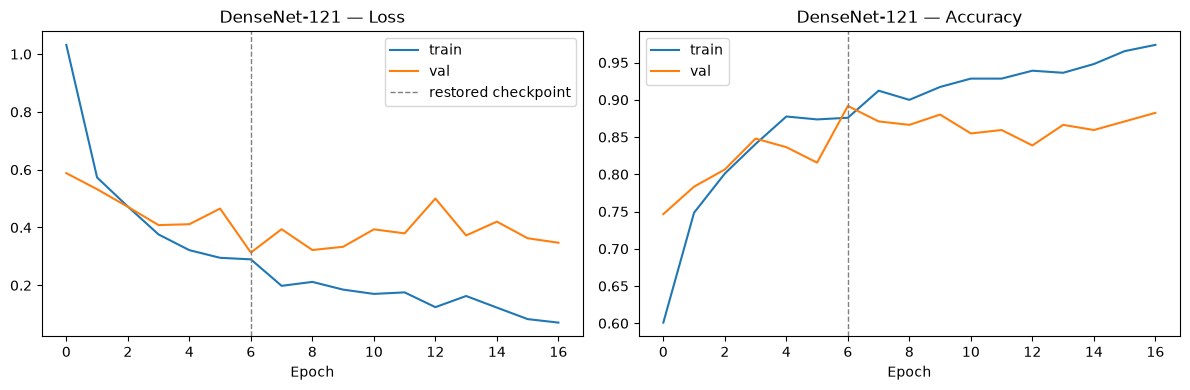

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "DenseNet-121", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "DenseNet-121")

## Evaluate on the test set

[DenseNet-121] Test accuracy: 0.880


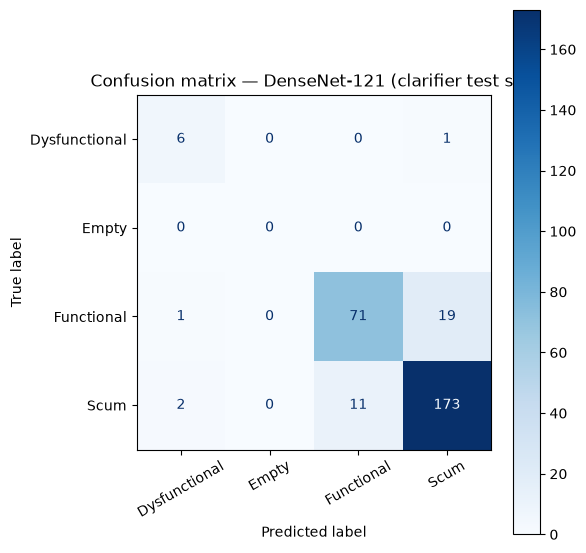

               precision    recall  f1-score   support

Dysfunctional      0.667     0.857     0.750         7
        Empty      0.000     0.000     0.000         0
   Functional      0.866     0.780     0.821        91
         Scum      0.896     0.930     0.913       186

     accuracy                          0.880       284
    macro avg      0.607     0.642     0.621       284
 weighted avg      0.881     0.880     0.879       284

  [warn] 'Empty' has 0 examples in this test set — AUC undefined, skipping.


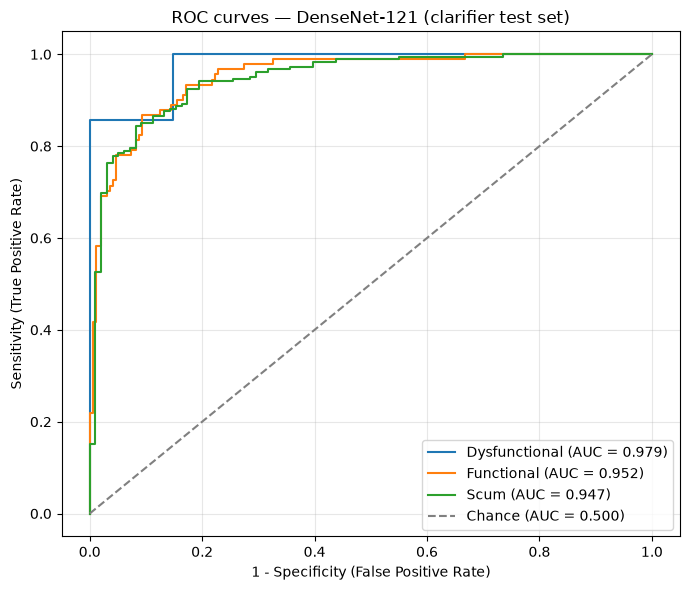

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.979
  Empty          : undefined (0 examples)
  Functional     : 0.952
  Scum           : 0.947

Mean AUC (over 3/4 classes with test examples): 0.959


(np.float64(0.8802816901408451),
 {'Dysfunctional': 0.9788550799381124,
  'Empty': nan,
  'Functional': 0.9520013665091386,
  'Scum': 0.9468948869870529})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "DenseNet-121", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("DenseNet-121", "densenet121")

Saved results to ../results/results_clarifier_densenet121_Waterval.pkl


Saved model weights to ../models/clarifier_densenet121_cnn.pt
